# 01 - Dataset y definicion del problema

Este notebook explica el punto de partida del proyecto. Las imagenes estan separadas en `train`, `validation` y `test`, y cada division tiene dos clases: `no_yawn` y `yawn`.

El objetivo es verificar cantidad de imagenes, balance entre clases y estructura correcta de carpetas antes de entrenar.


## Bloque 1: preparar rutas e importar librerias

Este bloque ubica la raiz del proyecto aunque el notebook se abra desde `notebooks`. Tambien importa las librerias usadas para contar imagenes y crear tablas. El resultado esperado es que `ROOT` apunte a `yawn-detection-mlp`.


In [9]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Markdown, display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.config import DATASET_DIR, CLASS_NAMES
from src.preprocessing import VALID_EXTENSIONS

ROOT


PosixPath('/mnt/c/Users/USUARIO/Documents/PARALELAS/yawn-detection-mlp')

## Bloque 2: contar imagenes por division y clase

Este bloque recorre `datasets/train`, `datasets/validation` y `datasets/test`. Solo cuenta archivos con extensiones validas, por ejemplo JPG, PNG, BMP o WEBP. El resultado esperado es una tabla con la cantidad de imagenes por clase.


In [10]:
rows = []
for split in ["train", "validation", "test"]:
    for class_name in CLASS_NAMES:
        folder = DATASET_DIR / split / class_name
        images = [path for path in folder.rglob("*") if path.suffix.lower() in VALID_EXTENSIONS]
        rows.append({"split": split, "class": class_name, "count": len(images)})

dataset_counts = pd.DataFrame(rows)
dataset_counts


,split,class,count
0,train,no_yawn,220
1,train,yawn,220
2,validation,no_yawn,47
3,validation,yawn,47
4,test,no_yawn,48
5,test,yawn,48


## Bloque 3: validar balance del dataset

Este bloque compara `no_yawn` contra `yawn` en cada division. Para la rubrica, el dataset debe estar balanceado y tener minimo 300 imagenes por clase en total. El resultado esperado es ver diferencias pequenas entre clases.


In [11]:
pivot = dataset_counts.pivot(index="split", columns="class", values="count")
pivot["difference"] = (pivot["yawn"] - pivot["no_yawn"]).abs()
pivot["total"] = pivot["yawn"] + pivot["no_yawn"]
pivot


class,no_yawn,yawn,difference,total
split,,,,
test,48,48,0,96
train,220,220,0,440
validation,47,47,0,94


## Bloque 4: revisar el total por clase

Este bloque suma las imagenes de todas las divisiones. Sirve para confirmar si cada clase supera el minimo solicitado. El resultado esperado es tener al menos 300 imagenes en `no_yawn` y al menos 300 en `yawn`.


In [12]:
totals = dataset_counts.groupby("class", as_index=False)["count"].sum()
totals["cumple_minimo_300"] = totals["count"] >= 300
totals


,class,count,cumple_minimo_300
0,no_yawn,315,True
1,yawn,315,True


## Bloque 5: mostrar la grafica de distribucion del dataset

Esta grafica es generada por el flujo del proyecto y se guarda en `metrics/dataset_distribution.png`. Ayuda a presentar visualmente que las clases estan balanceadas.


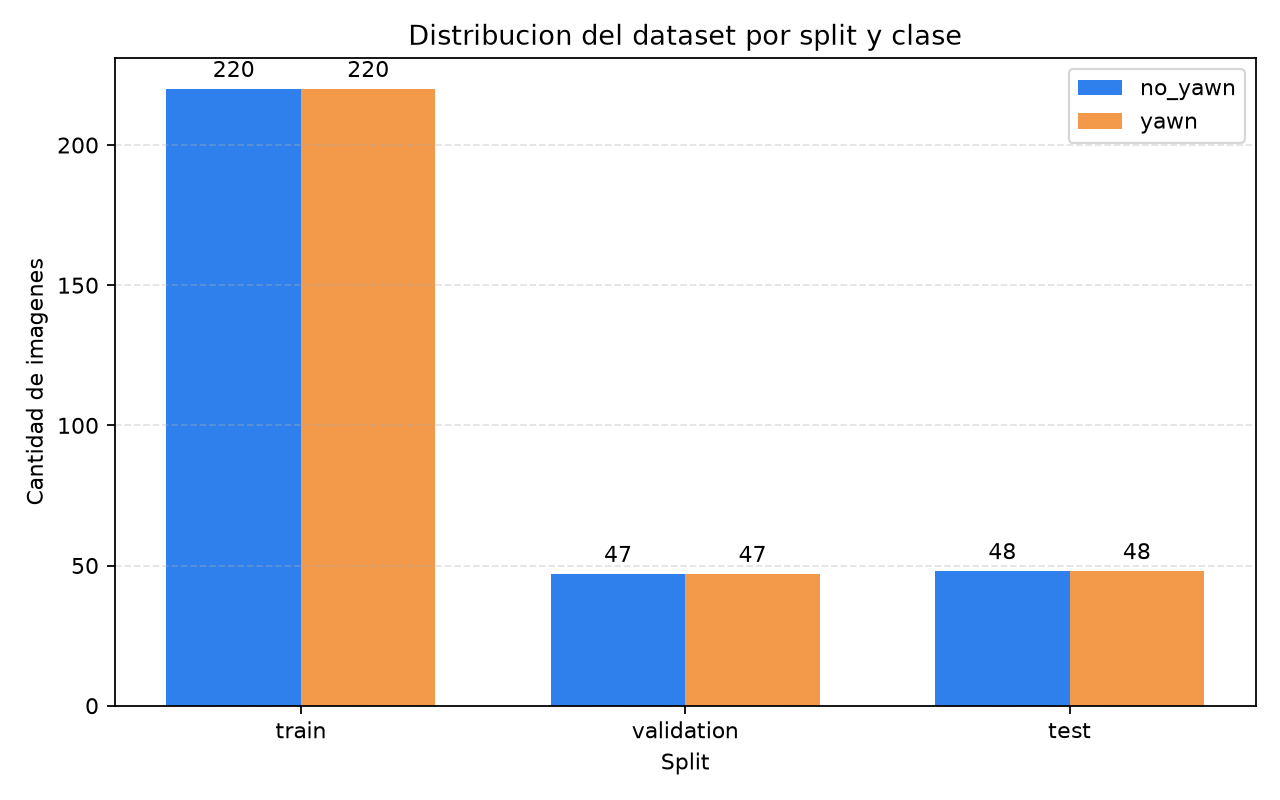

In [13]:
from IPython.display import Image, display

image_path = ROOT / "metrics" / "dataset_distribution.png"
if image_path.exists():
    display(Image(filename=str(image_path)))
else:
    print("La grafica aun no existe. Se genera despues de actualizar metricas o entrenar el flujo completo.")


## Bloque 6: leer el reporte del dataset

El archivo `metrics/dataset_summary.md` deja la evidencia en formato Markdown para VS Code y para el informe. Este bloque lo muestra directamente dentro del notebook si ya existe.


In [14]:
report_path = ROOT / "metrics" / "dataset_summary.md"
if report_path.exists():
    display(Markdown(report_path.read_text(encoding="utf-8")))
else:
    print("No existe metrics/dataset_summary.md. Puedes generarlo con: python -m tools.dataset_summary")


# Distribucion del dataset

| Division | No bostezo | Bostezo | Total |
|---|---:|---:|---:|
| train | 220 | 220 | 440 |
| validation | 47 | 47 | 94 |
| test | 48 | 48 | 96 |

**Total:** 630 imagenes.  
**Total no_yawn:** 315.  
**Total yawn:** 315.
